# 🔬 Notebook Auxiliar — Transformer na Prática
### Demonstração passo a passo do mecanismo de atenção e arquitetura Transformer

---

## 🎯 O que você vai ver

1. **Implementação do mecanismo de atenção do zero** — sem biblioteca, só NumPy
2. **Visualização dos pesos de atenção** — ver o que o modelo "olha"
3. **Positional Encoding** — como o Transformer sabe a ordem das palavras
4. **Transformer completo com Keras** — construir, treinar e inspecionar
5. **Extrair pesos de atenção do BERT** — inspecionar um modelo real
6. **Comparativo: RNN vs Transformer** — por que o Transformer ganhou

---

## 📚 Revisão Rápida

### O que é o mecanismo de atenção?

Cada palavra da frase calcula **quanto precisa prestar atenção em cada outra palavra**.  
Isso é feito com três vetores que o modelo aprende:

```
Query (Q)  → "O que estou buscando?"
Key   (K)  → "O que eu ofereço para quem busca?"
Value (V)  → "Qual é o meu conteúdo real?"
```

### A fórmula (sem medo!)

```
Attention(Q, K, V) = softmax( Q × Kᵀ / √d ) × V
                              ───────────────
                              score de atenção
```

- `Q × Kᵀ` → compara a pergunta com todas as chaves (produto escalar)
- `/ √d`   → divide pela raiz da dimensão (evita valores muito grandes)
- `softmax` → transforma scores em probabilidades (somam 1.0)
- `× V`    → usa essas probabilidades para combinar os valores

---

In [1]:
# ─────────────────────────────────────────────────────────────
# CONFIGURAÇÃO INICIAL
# ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel('ERROR')

print(f'✅ NumPy      : {np.__version__}')
print(f'✅ TensorFlow : {tf.__version__}')
print()
print('📌 Este notebook implementa o Transformer do zero, passo a passo.')
print('   Nenhum código é "mágica" — tudo será explicado linha a linha.')


✅ NumPy      : 1.26.4
✅ TensorFlow : 2.15.0

📌 Este notebook implementa o Transformer do zero, passo a passo.
   Nenhum código é "mágica" — tudo será explicado linha a linha.


---
## 🔵 Parte 1 — Atenção do Zero com NumPy

### 1.1 Implementando Scaled Dot-Product Attention

In [2]:
# ─────────────────────────────────────────────────────────────
# SCALED DOT-PRODUCT ATTENTION — Implementação manual
#
# Entrada:
#   Q (queries): shape (n_tokens, d_k)
#   K (keys)   : shape (n_tokens, d_k)
#   V (values) : shape (n_tokens, d_v)
#
# Saída:
#   output  : shape (n_tokens, d_v)  — representação enriquecida
#   weights : shape (n_tokens, n_tokens) — pesos de atenção
# ─────────────────────────────────────────────────────────────

def softmax(x):
    """
    Converte um vetor de scores em probabilidades.
    Cada valor fica entre 0 e 1, e a soma é sempre 1.0.

    exp(x) / sum(exp(x)) — fórmula matemática do softmax
    """
    # Subtrair o máximo evita overflow numérico (trick de estabilidade)
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)


def scaled_dot_product_attention(Q, K, V):
    """
    Mecanismo de atenção do paper 'Attention Is All You Need' (2017).

    Fórmula: Attention(Q,K,V) = softmax(Q @ K.T / sqrt(d_k)) @ V

    Passo a passo:
    1. Q @ K.T    → cada query compara com todas as keys (produto escalar)
    2. / sqrt(d_k) → escala para evitar gradientes muito pequenos
    3. softmax    → transforma scores em probabilidades
    4. @ V        → combina os values com os pesos calculados
    """
    d_k = Q.shape[-1]            # dimensão dos vetores (usado na escala)

    # Passo 1: calcular scores de atenção
    # scores[i,j] = quanto o token i presta atenção no token j
    scores = Q @ K.T             # shape: (n_tokens, n_tokens)

    # Passo 2: escalar pelo sqrt da dimensão
    # Sem isso, produtos escalares ficam muito grandes e o softmax
    # satura — retornando quase 1 para o maior e ~0 para os demais
    scores_scaled = scores / np.sqrt(d_k)

    # Passo 3: converter em probabilidades com softmax
    # Cada linha soma 1.0: token i distribui 100% de atenção
    weights = softmax(scores_scaled)  # shape: (n_tokens, n_tokens)

    # Passo 4: combinar os valores com os pesos
    # output[i] = soma ponderada de todos os values, com pesos de atenção
    output = weights @ V              # shape: (n_tokens, d_v)

    return output, weights


# ── Teste com vetores simples (apenas para verificar o funcionamento)
np.random.seed(42)
n_tokens = 4   # 4 palavras na frase
d_k      = 8   # dimensão dos vetores Q e K

Q_teste = np.random.randn(n_tokens, d_k)
K_teste = np.random.randn(n_tokens, d_k)
V_teste = np.random.randn(n_tokens, d_k)

output_teste, pesos_teste = scaled_dot_product_attention(Q_teste, K_teste, V_teste)

print('✅ scaled_dot_product_attention funcionando!\n')
print(f'   Entrada Q: shape {Q_teste.shape}  (4 tokens × 8 dims)')
print(f'   Saída   : shape {output_teste.shape}  (4 tokens × 8 dims)')
print(f'   Pesos   : shape {pesos_teste.shape}  (4×4 — cada token → todos)')
print()
print('   Verificação: cada linha de pesos soma 1.0?')
for i, soma in enumerate(pesos_teste.sum(axis=1)):
    print(f'   Token {i}: soma = {soma:.6f} ✅')

✅ scaled_dot_product_attention funcionando!

   Entrada Q: shape (4, 8)  (4 tokens × 8 dims)
   Saída   : shape (4, 8)  (4 tokens × 8 dims)
   Pesos   : shape (4, 4)  (4×4 — cada token → todos)

   Verificação: cada linha de pesos soma 1.0?
   Token 0: soma = 1.000000 ✅
   Token 1: soma = 1.000000 ✅
   Token 2: soma = 1.000000 ✅
   Token 3: soma = 1.000000 ✅


---
### 1.2 Visualizando Pesos de Atenção numa Frase Real

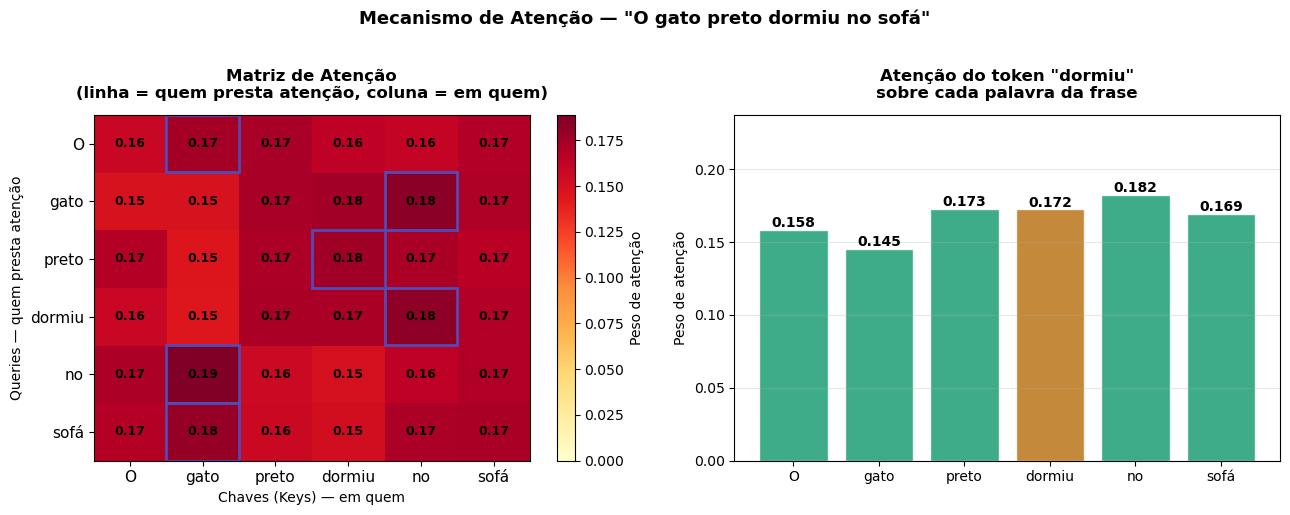


📊 Interpretação da matriz:
   Caixa roxa = token com maior atenção em cada linha
   Relações esperadas:
   O          presta mais atenção em: gato       (0.175)
   gato       presta mais atenção em: no         (0.184)
   preto      presta mais atenção em: dormiu     (0.176)
   dormiu     presta mais atenção em: no         (0.182)
   no         presta mais atenção em: gato       (0.189)
   sofá       presta mais atenção em: gato       (0.180)


In [3]:
# ─────────────────────────────────────────────────────────────
# SIMULAÇÃO DE ATENÇÃO EM UMA FRASE REAL
#
# Vamos simular como o Transformer 'raciocina' sobre a frase:
# "O gato preto dormiu no sofá"
#
# Usaremos embeddings simplificados que capturem relações
# semânticas básicas entre as palavras.
# ─────────────────────────────────────────────────────────────

tokens = ['O', 'gato', 'preto', 'dormiu', 'no', 'sofá']
n = len(tokens)
d = 16  # dimensão dos embeddings

np.random.seed(7)

# Embeddings: vetores que representam cada palavra
# Palavras relacionadas têm vetores mais similares
emb = np.random.randn(n, d) * 0.5

# Injetar relações semânticas manualmente (para fins didáticos)
# 'O' e 'gato' compartilham dims 0-2 (artigo refere ao substantivo)
emb[0, :3]  = [1.2, 0.8, 0.9]   # O
emb[1, :3]  = [1.0, 0.9, 1.1]   # gato — similar a 'O'
# 'preto' e 'gato' compartilham dims 2-4 (adjetivo modifica substantivo)
emb[2, 2:5] = [1.3, 1.2, 0.7]   # preto
emb[1, 2:5] = [1.1, 0.8, 0.6]   # gato (reforço)
# 'dormiu' e 'gato' dims 4-6 (verbo relacionado ao sujeito)
emb[3, 4:7] = [1.5, 1.3, 0.9]   # dormiu
emb[1, 4:7] = [1.3, 1.1, 0.7]   # gato (reforço)
# 'no' e 'sofá' dims 6-8 (preposição + objeto)
emb[4, 6:9] = [1.4, 1.2, 1.0]   # no
emb[5, 6:9] = [1.5, 1.3, 0.8]   # sofá — similar a 'no'

# Matrizes de projeção (aprendidas durante o treinamento)
# Transformam embeddings em Q, K, V
np.random.seed(42)
W_Q = np.random.randn(d, d) * 0.1
W_K = np.random.randn(d, d) * 0.1
W_V = np.random.randn(d, d) * 0.1

# Projetar embeddings em Q, K, V
Q = emb @ W_Q   # Queries: o que cada token busca?
K = emb @ W_K   # Keys: o que cada token oferece?
V = emb @ W_V   # Values: o conteúdo de cada token

# Calcular atenção
output_frase, pesos_frase = scaled_dot_product_attention(Q, K, V)

# ── Visualizar a matriz de atenção
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap dos pesos
im = ax1.imshow(pesos_frase, cmap='YlOrRd', aspect='auto',
                vmin=0, vmax=pesos_frase.max())
ax1.set_xticks(range(n))
ax1.set_yticks(range(n))
ax1.set_xticklabels(tokens, fontsize=11)
ax1.set_yticklabels(tokens, fontsize=11)
ax1.set_title('Matriz de Atenção\n(linha = quem presta atenção, coluna = em quem)',
              fontweight='bold', pad=12)
ax1.set_xlabel('Chaves (Keys) — em quem')
ax1.set_ylabel('Queries — quem presta atenção')
plt.colorbar(im, ax=ax1, label='Peso de atenção')

# Adicionar valores nas células
for i in range(n):
    for j in range(n):
        val = pesos_frase[i, j]
        cor = 'white' if val > 0.22 else 'black'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color=cor)

# Destacar o token com maior atenção em cada linha
for i in range(n):
    j_max = np.argmax(pesos_frase[i])
    ax1.add_patch(plt.Rectangle((j_max-0.5, i-0.5), 1, 1,
                                  fill=False, edgecolor='#534AB7', linewidth=2))

# Gráfico de barras: foco do token 'dormiu' (índice 3)
token_foco = 3  # 'dormiu'
cores_bar = ['#1D9E75' if j != token_foco else '#BA7517' for j in range(n)]
bars = ax2.bar(tokens, pesos_frase[token_foco], color=cores_bar, alpha=0.85,
               edgecolor='white')
ax2.set_title(f'Atenção do token "{tokens[token_foco]}"\nsobre cada palavra da frase',
              fontweight='bold', pad=12)
ax2.set_ylabel('Peso de atenção')
ax2.set_ylim(0, pesos_frase[token_foco].max() * 1.3)
ax2.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, pesos_frase[token_foco]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Mecanismo de Atenção — "O gato preto dormiu no sofá"',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\n📊 Interpretação da matriz:')
print('   Caixa roxa = token com maior atenção em cada linha')
print('   Relações esperadas:')
for i, tok in enumerate(tokens):
    j_max = np.argmax(pesos_frase[i])
    print(f'   {tok:<10} presta mais atenção em: {tokens[j_max]:<10} ({pesos_frase[i,j_max]:.3f})')

---
## 🟢 Parte 2 — Positional Encoding

### Por que o Transformer precisa saber a posição das palavras?

A atenção por si só é **invariante à posição** — se você embaralhar as palavras da frase,  
os pesos seriam os mesmos! O Transformer resolve isso somando um **vetor de posição**  
ao embedding de cada token antes do processamento.

O Positional Encoding usa funções seno e cosseno com diferentes frequências,  
gerando um padrão único para cada posição sem precisar ser treinado.

✅ Positional Encoding gerado: shape (50, 64)
   50 posições × 64 dimensões



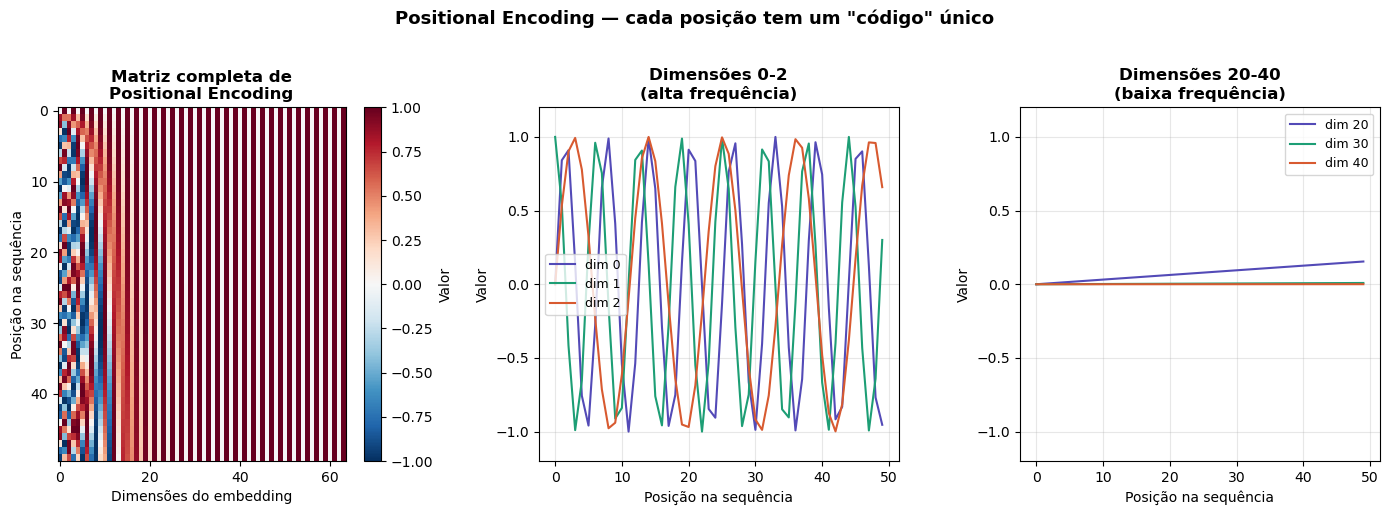

📏 Similaridade entre vetores de posição (cosine similarity):
   pos 0 ↔ pos  1 : 0.9786  (próximos → similar)
   pos 0 ↔ pos 10 : 0.8143
   pos 0 ↔ pos 49 : 0.6739  (distantes → menos similar)

💡 Posições próximas têm vetores mais similares!


In [4]:
# ─────────────────────────────────────────────────────────────
# POSITIONAL ENCODING
#
# Para cada posição pos e cada dimensão i:
#   PE[pos, 2i]   = sin(pos / 10000^(2i/d_model))
#   PE[pos, 2i+1] = cos(pos / 10000^(2i/d_model))
#
# Por que seno e cosseno?
#   - Valores sempre entre -1 e 1 (estável numericamente)
#   - Padrão único para cada posição
#   - O modelo pode aprender relações de posição relativa:
#     PE[pos+k] pode ser expresso como função linear de PE[pos]
# ─────────────────────────────────────────────────────────────

def positional_encoding(max_pos, d_model):
    """
    Gera a matriz de positional encoding.

    Parâmetros:
        max_pos  : número máximo de posições (comprimento da sequência)
        d_model  : dimensão do modelo (mesmo que o embedding)

    Retorna:
        PE : matriz (max_pos, d_model) com os vetores de posição
    """
    # Criar a matriz de zeros
    PE = np.zeros((max_pos, d_model))

    # Vetor de posições: [0, 1, 2, ..., max_pos-1]
    posicoes = np.arange(max_pos).reshape(-1, 1)   # shape (max_pos, 1)

    # Fatores de escala para cada par de dimensões
    # i = [0, 2, 4, ..., d_model-2]  (dimensões pares)
    i = np.arange(0, d_model, 2)      # shape (d_model/2,)

    # Divisor: 10000^(2i / d_model)
    # Cada par de dimensões usa uma frequência diferente:
    #   - Dimensões baixas: frequência alta → variação rápida entre posições vizinhas
    #   - Dimensões altas: frequência baixa → variação lenta (captura posição global)
    divisor = np.power(10000, 2 * i / d_model)     # shape (d_model/2,)

    # Preencher dimensões pares com seno
    PE[:, 0::2] = np.sin(posicoes / divisor)

    # Preencher dimensões ímpares com cosseno
    PE[:, 1::2] = np.cos(posicoes / divisor)

    return PE


# Gerar PE para 50 posições e 64 dimensões
MAX_POS  = 50
D_MODEL  = 64
PE = positional_encoding(MAX_POS, D_MODEL)

print(f'✅ Positional Encoding gerado: shape {PE.shape}')
print(f'   {MAX_POS} posições × {D_MODEL} dimensões')
print()

# Visualizar a matriz de PE
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Heatmap completo
im = axes[0].imshow(PE, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Matriz completa de\nPositional Encoding', fontweight='bold')
axes[0].set_xlabel('Dimensões do embedding')
axes[0].set_ylabel('Posição na sequência')
plt.colorbar(im, ax=axes[0], label='Valor')

# ── Primeiras dimensões (alta frequência)
for dim, cor in [(0, '#534AB7'), (1, '#1D9E75'), (2, '#D85A30')]:
    axes[1].plot(PE[:, dim], label=f'dim {dim}', color=cor, linewidth=1.5)
axes[1].set_title('Dimensões 0-2\n(alta frequência)', fontweight='bold')
axes[1].set_xlabel('Posição na sequência')
axes[1].set_ylabel('Valor')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(-1.2, 1.2)

# ── Dimensões mais altas (baixa frequência)
for dim, cor in [(20, '#534AB7'), (30, '#1D9E75'), (40, '#D85A30')]:
    axes[2].plot(PE[:, dim], label=f'dim {dim}', color=cor, linewidth=1.5)
axes[2].set_title('Dimensões 20-40\n(baixa frequência)', fontweight='bold')
axes[2].set_xlabel('Posição na sequência')
axes[2].set_ylabel('Valor')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)
axes[2].set_ylim(-1.2, 1.2)

plt.suptitle('Positional Encoding — cada posição tem um "código" único',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Verificar que posições diferentes têm vetores diferentes
sim_01 = np.dot(PE[0], PE[1]) / (np.linalg.norm(PE[0]) * np.linalg.norm(PE[1]))
sim_10 = np.dot(PE[0], PE[10]) / (np.linalg.norm(PE[0]) * np.linalg.norm(PE[10]))
sim_49 = np.dot(PE[0], PE[49]) / (np.linalg.norm(PE[0]) * np.linalg.norm(PE[49]))

print('📏 Similaridade entre vetores de posição (cosine similarity):')
print(f'   pos 0 ↔ pos  1 : {sim_01:.4f}  (próximos → similar)')
print(f'   pos 0 ↔ pos 10 : {sim_10:.4f}')
print(f'   pos 0 ↔ pos 49 : {sim_49:.4f}  (distantes → menos similar)')
print('\n💡 Posições próximas têm vetores mais similares!')

---
## 🟡 Parte 3 — Multi-Head Attention

### Por que múltiplas cabeças?

Em vez de calcular a atenção uma única vez, o Transformer a calcula **H vezes em paralelo**,  
cada uma com matrizes W_Q, W_K, W_V diferentes.  
Cada **cabeça** aprende a prestar atenção em um tipo diferente de relação:

```
Cabeça 1 → pode aprender relações sintáticas (sujeito-verbo)
Cabeça 2 → pode aprender relações semânticas (sinônimos)
Cabeça 3 → pode aprender referências (pronome → antecedente)
...
```
No final, as saídas de todas as cabeças são **concatenadas** e projetadas.

✅ Multi-Head Attention com 4 cabeças
   Entrada : (6, 16)  (6 tokens × 16 dims)
   Saída   : (6, 16)  (mesmo shape — informação enriquecida)
   Pesos   : 4 cabeças × (6, 6)


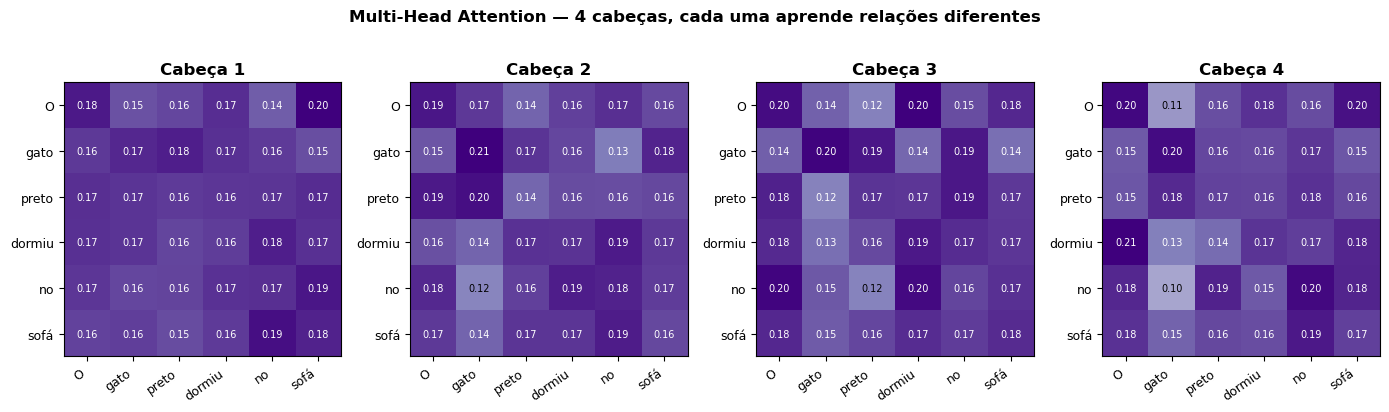


💡 Cada cabeça foca em padrões diferentes na mesma frase!


In [5]:
# ─────────────────────────────────────────────────────────────
# MULTI-HEAD ATTENTION — Implementação manual
#
# h cabeças de atenção em paralelo:
#   head_i = Attention(X @ W_Q_i, X @ W_K_i, X @ W_V_i)
#   output = concat(head_1, ..., head_h) @ W_O
# ─────────────────────────────────────────────────────────────

def multi_head_attention(X, n_heads, d_model):
    """
    Multi-Head Attention implementado do zero.

    Parâmetros:
        X       : embeddings de entrada, shape (n_tokens, d_model)
        n_heads : número de cabeças de atenção
        d_model : dimensão total do modelo

    Retorna:
        output  : shape (n_tokens, d_model)
        all_weights : lista com os pesos de cada cabeça
    """
    n_tokens = X.shape[0]

    # Cada cabeça opera em d_k dimensões (partição do d_model)
    d_k = d_model // n_heads

    head_outputs = []   # saídas de cada cabeça
    all_weights  = []   # pesos de atenção de cada cabeça

    for h in range(n_heads):
        # Cada cabeça tem suas próprias matrizes de projeção (simuladas)
        np.random.seed(h * 10 + 1)
        W_Q_h = np.random.randn(d_model, d_k) * 0.1
        W_K_h = np.random.randn(d_model, d_k) * 0.1
        W_V_h = np.random.randn(d_model, d_k) * 0.1

        # Projetar entradas
        Q_h = X @ W_Q_h   # (n_tokens, d_k)
        K_h = X @ W_K_h   # (n_tokens, d_k)
        V_h = X @ W_V_h   # (n_tokens, d_k)

        # Calcular atenção para esta cabeça
        head_out, weights_h = scaled_dot_product_attention(Q_h, K_h, V_h)

        head_outputs.append(head_out)    # (n_tokens, d_k)
        all_weights.append(weights_h)    # (n_tokens, n_tokens)

    # Concatenar todas as cabeças
    # De (n_heads, n_tokens, d_k) para (n_tokens, d_model)
    concat = np.concatenate(head_outputs, axis=-1)   # (n_tokens, d_model)

    # Projeção final W_O
    np.random.seed(99)
    W_O = np.random.randn(d_model, d_model) * 0.1
    output = concat @ W_O

    return output, all_weights


# ── Testar com a frase do exemplo
n_heads  = 4
d_model  = 16

# Embedding simples: cada palavra → vetor aleatório
np.random.seed(42)
X_frase = np.random.randn(len(tokens), d_model)

output_mha, pesos_por_cabeca = multi_head_attention(X_frase, n_heads, d_model)

print(f'✅ Multi-Head Attention com {n_heads} cabeças')
print(f'   Entrada : {X_frase.shape}  ({len(tokens)} tokens × {d_model} dims)')
print(f'   Saída   : {output_mha.shape}  (mesmo shape — informação enriquecida)')
print(f'   Pesos   : {len(pesos_por_cabeca)} cabeças × {pesos_por_cabeca[0].shape}')

# ── Visualizar pesos de cada cabeça
fig, axes = plt.subplots(1, n_heads, figsize=(14, 4))

for h, (ax, pesos) in enumerate(zip(axes, pesos_por_cabeca)):
    im = ax.imshow(pesos, cmap='Purples', vmin=0, vmax=pesos.max(),
                   aspect='auto', interpolation='nearest')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=35, ha='right', fontsize=9)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_title(f'Cabeça {h+1}', fontweight='bold')
    for i in range(len(tokens)):
        for j in range(len(tokens)):
            val = pesos[i, j]
            cor = 'white' if val > pesos.max() * 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color=cor)

plt.suptitle(f'Multi-Head Attention — {n_heads} cabeças, cada uma aprende relações diferentes',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 Cada cabeça foca em padrões diferentes na mesma frase!')

---
## 🔴 Parte 4 — Transformer Completo com Keras

### Construindo uma camada Transformer de verdade

In [7]:
# ─────────────────────────────────────────────────────────────
# CONFIGURAÇÃO — execute esta célula primeiro
# ─────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ── Redefinir a classe CamadaTransformer (necessário se o kernel foi reiniciado)
class CamadaTransformer(keras.layers.Layer):
    """
    Uma única camada Transformer — o bloco fundamental.
    Herda de keras.layers.Layer (não de keras.Model).
    Por isso, usa ._layers internamente, não .layers.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout_rate=0.1):
        super().__init__()
        self.atencao   = keras.layers.MultiHeadAttention(
                             num_heads=n_heads,
                             key_dim=d_model // n_heads,
                             name='multi_head_attention')
        self.ffn       = keras.Sequential([
                             keras.layers.Dense(d_ff,     activation='relu', name='ffn_expande'),
                             keras.layers.Dense(d_model,  name='ffn_contrai'),
                         ], name='feed_forward')
        self.norm1     = keras.layers.LayerNormalization(epsilon=1e-6, name='norm_1')
        self.norm2     = keras.layers.LayerNormalization(epsilon=1e-6, name='norm_2')
        self.dropout1  = keras.layers.Dropout(dropout_rate)
        self.dropout2  = keras.layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        attn_out = self.atencao(query=x, key=x, value=x, training=training)
        attn_out = self.dropout1(attn_out, training=training)
        x = self.norm1(x + attn_out)
        ffn_out  = self.ffn(x)
        ffn_out  = self.dropout2(ffn_out, training=training)
        x = self.norm2(x + ffn_out)
        return x

print('✅ CamadaTransformer redefinida!')

✅ CamadaTransformer redefinida!


In [8]:
# ─────────────────────────────────────────────────────────────
# TESTAR A CAMADA — shape de entrada e saída
# ─────────────────────────────────────────────────────────────
import numpy as np

D_MODEL  = 32
N_HEADS  = 4
D_FF     = 128
N_TOKENS = 6
BATCH    = 2

camada_tf = CamadaTransformer(D_MODEL, N_HEADS, D_FF)

x_teste = tf.random.normal((BATCH, N_TOKENS, D_MODEL))
saida   = camada_tf(x_teste, training=False)

print('✅ CamadaTransformer funcionando!')
print(f'   Entrada : {x_teste.shape}  (batch={BATCH}, tokens={N_TOKENS}, dims={D_MODEL})')
print(f'   Saída   : {saida.shape}   (mesmo shape — informação enriquecida)')

✅ CamadaTransformer funcionando!
   Entrada : (2, 6, 32)  (batch=2, tokens=6, dims=32)
   Saída   : (2, 6, 32)   (mesmo shape — informação enriquecida)


In [9]:
# ─────────────────────────────────────────────────────────────
# INSPECIONAR COMPONENTES INTERNOS — 3 formas corretas
#
# keras.layers.Layer NÃO tem .layers  ← causa do AttributeError
# keras.Model         TEM  .layers    ← apenas modelos completos
#
# Para uma Layer, use uma das 3 abordagens abaixo:
# ─────────────────────────────────────────────────────────────

print('─' * 55)
print('  Forma 1 — listar atributos que são sub-camadas')
print('─' * 55)

# Iterar sobre os atributos do objeto e filtrar os que
# são instâncias de keras.layers.Layer
for nome, valor in vars(camada_tf).items():
    if isinstance(valor, keras.layers.Layer):
        tipo  = type(valor).__name__
        print(f'   {nome:<18} → {tipo}')

print()
print('─' * 55)
print('  Forma 2 — _flatten_layers() (API interna do Keras)')
print('─' * 55)

# _flatten_layers() percorre recursivamente toda a hierarquia,
# incluindo sub-camadas dentro de Sequential
for subcamada in camada_tf._flatten_layers(include_self=False):
    n_params = sum(w.numpy().size for w in subcamada.trainable_weights)
    print(f'   {subcamada.name:<30} parâmetros treináveis: {n_params:,}')

print()
print('─' * 55)
print('  Forma 3 — wrapping em keras.Model para usar .summary()')
print('─' * 55)

# A forma mais visual: envolver a Layer em um Model
# Assim podemos usar .summary() normalmente
entrada_model  = keras.Input(shape=(N_TOKENS, D_MODEL), name='entrada')
saida_model    = camada_tf(entrada_model)
modelo_inspec  = keras.Model(inputs=entrada_model, outputs=saida_model,
                              name='CamadaTransformer_wrapper')

print()
modelo_inspec.summary()

print()
total_params = sum(w.numpy().size for w in camada_tf.trainable_weights)
print(f'Total de parâmetros treináveis: {total_params:,}')

───────────────────────────────────────────────────────
  Forma 1 — listar atributos que são sub-camadas
───────────────────────────────────────────────────────
   atencao            → MultiHeadAttention
   ffn                → Sequential
   norm1              → LayerNormalization
   norm2              → LayerNormalization
   dropout1           → Dropout
   dropout2           → Dropout

───────────────────────────────────────────────────────
  Forma 2 — _flatten_layers() (API interna do Keras)
───────────────────────────────────────────────────────
   multi_head_attention           parâmetros treináveis: 4,224
   query                          parâmetros treináveis: 1,056
   key                            parâmetros treináveis: 1,056
   value                          parâmetros treináveis: 1,056
   softmax_1                      parâmetros treináveis: 0
   dropout_5                      parâmetros treináveis: 0
   attention_output               parâmetros treináveis: 1,056
   feed_forw

In [10]:
# ─────────────────────────────────────────────────────────────
# RESUMO: quando usar .layers vs _flatten_layers()
# ─────────────────────────────────────────────────────────────

print('📋 Referência rápida — inspeção de modelos Keras\n')
print(f'{"Objeto":<30} {"Atributo":<30} {"Quando usar"}')
print('─' * 80)

referencia = [
    ('keras.Model',          '.layers',                  'Modelos completos (Sequential, Functional)'),
    ('keras.Model',          '.summary()',               'Tabela detalhada de camadas e parâmetros'),
    ('keras.layers.Layer',   'vars(obj).items()',         'Listar atributos que são sub-camadas'),
    ('keras.layers.Layer',   '._flatten_layers()',        'Todos os pesos e sub-camadas recursivamente'),
    ('keras.Model / Layer',  '.trainable_weights',        'Lista de tensores de pesos treináveis'),
    ('keras.Model / Layer',  '.count_params()',           'Total de parâmetros (requer build prévia)'),
]

for obj, attr, uso in referencia:
    print(f'{obj:<30} {attr:<30} {uso}')

print()
print('💡 Dica: envolva qualquer Layer em keras.Model para acessar .summary() e .layers')
print('   entrada = keras.Input(shape=(seq, d_model))')
print('   saida   = minha_layer(entrada)')
print('   modelo  = keras.Model(inputs=entrada, outputs=saida)')
print('   modelo.summary()   # funciona!')

📋 Referência rápida — inspeção de modelos Keras

Objeto                         Atributo                       Quando usar
────────────────────────────────────────────────────────────────────────────────
keras.Model                    .layers                        Modelos completos (Sequential, Functional)
keras.Model                    .summary()                     Tabela detalhada de camadas e parâmetros
keras.layers.Layer             vars(obj).items()              Listar atributos que são sub-camadas
keras.layers.Layer             ._flatten_layers()             Todos os pesos e sub-camadas recursivamente
keras.Model / Layer            .trainable_weights             Lista de tensores de pesos treináveis
keras.Model / Layer            .count_params()                Total de parâmetros (requer build prévia)

💡 Dica: envolva qualquer Layer em keras.Model para acessar .summary() e .layers
   entrada = keras.Input(shape=(seq, d_model))
   saida   = minha_layer(entrada)
   modelo  = kera

---
### 4.2 Modelo Completo: Classificador de Texto com Transformer

In [12]:
# ─────────────────────────────────────────────────────────────
# CLASSIFICADOR DE SENTIMENTO COM TRANSFORMER
#
# Arquitetura completa:
#   Texto → TokenIDs → Embedding + PosEnc → Transformer × 2
#   → GlobalAvgPool → Dense → Saída (positivo/negativo)
# ─────────────────────────────────────────────────────────────

def criar_modelo_transformer(
    vocab_size, max_len, d_model, n_heads, d_ff, n_camadas, dropout=0.1
):
    """
    Cria um modelo Transformer completo para classificação de texto.

    Parâmetros:
        vocab_size : tamanho do vocabulário
        max_len    : comprimento máximo da sequência
        d_model    : dimensão do modelo (embedding)
        n_heads    : número de cabeças de atenção
        d_ff       : dimensão da rede feed-forward
        n_camadas  : quantas camadas Transformer empilhar
        dropout    : taxa de dropout
    """
    # ── Entrada: sequência de IDs de tokens
    entrada = keras.Input(shape=(max_len,), name='tokens')

    # ── Embedding de palavras
    x = keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=d_model,
        name='word_embedding'
    )(entrada)

    # ── Positional Encoding
    # Vetor de posições [0, 1, 2, ..., max_len-1]
    posicoes = tf.range(start=0, limit=max_len, delta=1)
    pos_emb = keras.layers.Embedding(
        input_dim=max_len,
        output_dim=d_model,
        name='positional_embedding'
    )(posicoes)

    # Somar palavra + posição
    x = x + pos_emb
    x = keras.layers.Dropout(dropout)(x)

    # ── N camadas Transformer empilhadas
    for i in range(n_camadas):
        x = CamadaTransformer(
            d_model, n_heads, d_ff, dropout
        )(x)

    # ── Agregar a sequência em um único vetor
    x = keras.layers.GlobalAveragePooling1D(name='pooling')(x)

    # ── Classificador
    x = keras.layers.Dense(32, activation='relu', name='classificador')(x)
    x = keras.layers.Dropout(dropout)(x)
    saida = keras.layers.Dense(1, activation='sigmoid', name='saida')(x)

    modelo = keras.Model(inputs=entrada, outputs=saida,
                          name='transformer_classificador')
    return modelo


# ── Configuração e dataset
VOCAB_SIZE  = 300
MAX_LEN     = 12
D_MODEL     = 32
N_HEADS     = 4
D_FF        = 128
N_CAMADAS   = 2

# Dataset de reviews
reviews = [
    'this movie is absolutely wonderful and amazing',
    'brilliant performance by the actors loved it',
    'outstanding story and beautiful cinematography',
    'one of the best films i have ever seen',
    'incredible acting and stunning visuals loved',
    'masterpiece of cinema highly recommended film',
    'superb direction and excellent writing loved',
    'wonderful story with amazing characters great',
    'terrible movie waste of time and money awful',
    'boring and predictable plot with bad acting',
    'worst film i have ever seen dreadful horrible',
    'horrible story and terrible direction awful',
    'complete disaster awful and very boring film',
    'dreadful script and poor performances bad',
    'terribly written and very disappointing movie',
    'horrible film terrible music awful screenplay',
]
labels = [1]*8 + [0]*8

# Vetorizar
vetorizador_tr = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN,
    standardize='lower_and_strip_punctuation'
)
vetorizador_tr.adapt(reviews)

X_tr = vetorizador_tr(reviews).numpy()
y_tr = np.array(labels)

# Criar e compilar o modelo
modelo_transformer = criar_modelo_transformer(
    VOCAB_SIZE, MAX_LEN, D_MODEL, N_HEADS, D_FF, N_CAMADAS
)
modelo_transformer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('🏗️  Arquitetura do Modelo Transformer:')
modelo_transformer.summary()

# Treinar
print('\n🎓 Treinando...')
hist_tr = modelo_transformer.fit(
    X_tr, y_tr,
    epochs=60,
    batch_size=8,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='accuracy', patience=10, restore_best_weights=True
        )
    ]
)
acc = hist_tr.history['accuracy'][-1]
print(f'✅ Acurácia final: {acc:.2%}')

🏗️  Arquitetura do Modelo Transformer:
Model: "transformer_classificador"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 tokens (InputLayer)         [(None, 12)]              0         
                                                                 
 word_embedding (Embedding)  (None, 12, 32)            9600      
                                                                 
 tf.__operators__.add (TFOp  (None, 12, 32)            0         
 Lambda)                                                         
                                                                 
 dropout_9 (Dropout)         (None, 12, 32)            0         
                                                                 
 camada_transformer_3 (Cama  (None, 12, 32)            12704     
 daTransformer)                                                  
                                                                 
 c

---
## 🟣 Parte 5 — Inspecionando Pesos Reais do BERT

In [13]:
# ─────────────────────────────────────────────────────────────
# EXTRAINDO PESOS DE ATENÇÃO DO BERT REAL
# Vamos ver o que o DistilBERT realmente "olha" ao processar
# uma frase — cada cabeça de atenção produz padrões únicos
# ─────────────────────────────────────────────────────────────

from transformers import AutoTokenizer, AutoModel
import torch

MODELO_ID = 'distilbert-base-uncased'
print(f'🔄 Carregando {MODELO_ID}...')

tok_bert  = AutoTokenizer.from_pretrained(MODELO_ID)
bert      = AutoModel.from_pretrained(MODELO_ID, output_attentions=True)
bert.eval()
print('✅ Modelo carregado!\n')

# Frase para análise
frase_bert = 'I went to the bank to withdraw some money'
tokens_bert = tok_bert.tokenize(frase_bert)
tokens_exib = ['[CLS]'] + tokens_bert + ['[SEP]']

# Processar
inputs = tok_bert(frase_bert, return_tensors='pt')
with torch.no_grad():
    outputs = bert(**inputs)

# DistilBERT tem 6 camadas, cada uma com 12 cabeças
# outputs.attentions: tupla de (n_camadas,) tensores shape (batch, n_heads, seq, seq)
atencoes = outputs.attentions

print(f'📐 Estrutura dos pesos de atenção:')
print(f'   Camadas    : {len(atencoes)}')
print(f'   Cabeças    : {atencoes[0].shape[1]}')
print(f'   Tokens     : {atencoes[0].shape[2]} (incluindo [CLS] e [SEP])')
print(f'   Frase      : "{frase_bert}"')
print(f'   Tokens     : {tokens_exib}')

# ── Visualizar todas as cabeças da primeira camada
camada_exib = 0  # primeira camada
n_heads_bert = atencoes[camada_exib].shape[1]
pesos_camada = atencoes[camada_exib][0].detach().numpy()  # (n_heads, seq, seq)

n_tok = len(tokens_exib)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
axes = axes.flatten()

for h in range(n_heads_bert):
    ax = axes[h]
    pesos_h = pesos_camada[h, :n_tok, :n_tok]
    im = ax.imshow(pesos_h, cmap='Blues', aspect='auto',
                   vmin=0, vmax=pesos_h.max(), interpolation='nearest')
    ax.set_xticks(range(n_tok))
    ax.set_yticks(range(n_tok))
    ax.set_xticklabels(tokens_exib, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(tokens_exib, fontsize=7)
    ax.set_title(f'Cabeça {h+1}', fontsize=9, fontweight='bold')

plt.suptitle(f'DistilBERT — Pesos de Atenção (Camada 1, 12 cabeças)\n"{frase_bert}"',
             fontweight='bold', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Analisar qual token "bank" mais atende
idx_bank = tokens_exib.index('bank')
print(f'\n🔍 Análise do token "bank" em cada cabeça (camada 1):')
print(f'   {"Cabeça":<10} {"Token com maior atenção":<25} {"Peso"}')
print('   ' + '-' * 45)
for h in range(n_heads_bert):
    pesos_h = pesos_camada[h, idx_bank, :n_tok]
    j_max   = np.argmax(pesos_h)
    print(f'   Cabeça {h+1:<4} {tokens_exib[j_max]:<25} {pesos_h[j_max]:.4f}')

OSError: [WinError 182] O sistema operacional não pode executar %1. Error loading "C:\Users\Anderson\.conda\envs\pln-curso\lib\site-packages\torch\lib\fbgemm.dll" or one of its dependencies.

---
## 🔶 Parte 6 — Comparativo: RNN vs Transformer

⚡ Treinando LSTM...
⚡ Já treinamos o Transformer anteriormente.


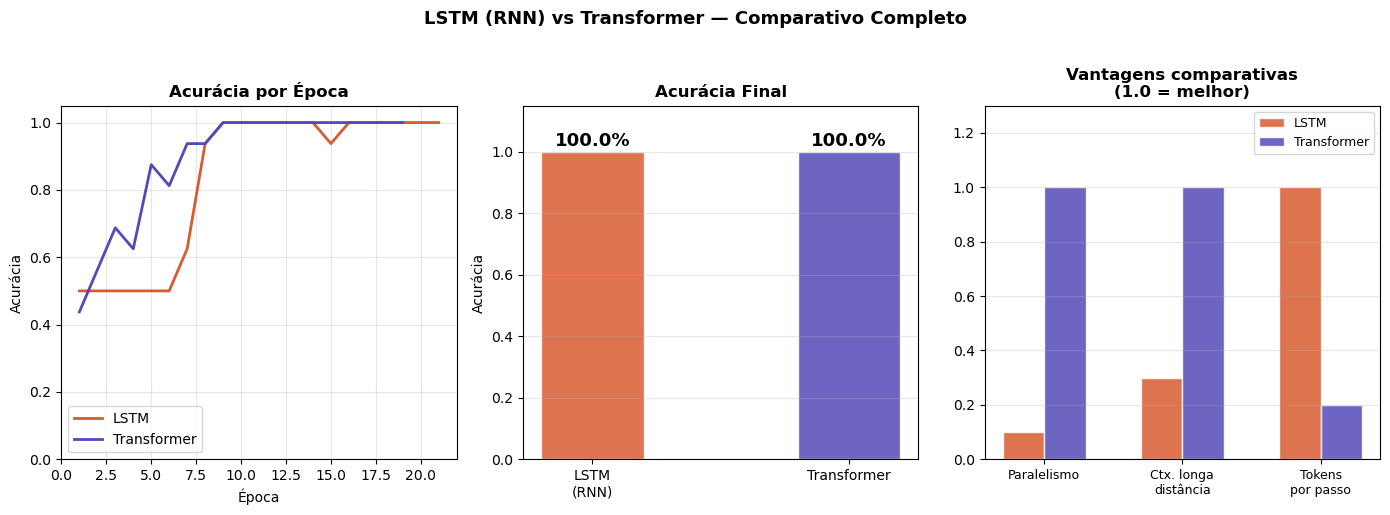


📊 Vantagens do Transformer sobre RNNs:
   Paralelismo   : processa todos os tokens ao mesmo tempo (treina muito mais rápido)
   Ctx. distante : atenção conecta qualquer par de tokens diretamente
   Escalabilidade: mais dados + mais camadas = modelos maiores e melhores


In [14]:
# ─────────────────────────────────────────────────────────────
# COMPARATIVO: RNN vs TRANSFORMER
#
# Problema clássico que ilustra a limitação das RNNs:
# dependências de longa distância
#
# Frase: "O livro que meu amigo que mora em São Paulo
#          comprou ontem foi ótimo"
#
# Para entender "foi ótimo", precisamos conectar com "livro"
# — 9 palavras de distância!
# ─────────────────────────────────────────────────────────────

def criar_modelo_rnn(vocab_size, max_len, d_emb, d_rnn):
    """Modelo LSTM para comparação."""
    m = keras.Sequential([
        keras.layers.Embedding(vocab_size, d_emb),
        keras.layers.LSTM(d_rnn, return_sequences=False),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid'),
    ], name='lstm_classificador')
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m


# Treinar ambos os modelos com os mesmos dados
modelo_rnn = criar_modelo_rnn(VOCAB_SIZE, MAX_LEN, D_MODEL, D_MODEL)

print('⚡ Treinando LSTM...')
hist_rnn = modelo_rnn.fit(
    X_tr, y_tr, epochs=80, batch_size=8, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='accuracy', patience=12, restore_best_weights=True)]
)

print('⚡ Já treinamos o Transformer anteriormente.')

acc_rnn = max(hist_rnn.history['accuracy'])
acc_tfm = max(hist_tr.history['accuracy'])

# ── Comparativo visual completo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Gráfico 1: Acurácia por época
epocas_rnn = range(1, len(hist_rnn.history['accuracy']) + 1)
epocas_tfm = range(1, len(hist_tr.history['accuracy']) + 1)
axes[0].plot(epocas_rnn, hist_rnn.history['accuracy'],
             color='#D85A30', lw=2, label='LSTM')
axes[0].plot(epocas_tfm, hist_tr.history['accuracy'],
             color='#534AB7', lw=2, label='Transformer')
axes[0].set_title('Acurácia por Época', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Gráfico 2: Acurácia final
modelos_nomes = ['LSTM\n(RNN)', 'Transformer']
accs_finais   = [acc_rnn, acc_tfm]
cores_final   = ['#D85A30', '#534AB7']
bars = axes[1].bar(modelos_nomes, accs_finais, color=cores_final, alpha=0.85,
                    edgecolor='white', width=0.4)
axes[1].set_title('Acurácia Final', fontweight='bold')
axes[1].set_ylabel('Acurácia')
axes[1].set_ylim(0, 1.15)
axes[1].grid(alpha=0.3, axis='y')
for bar, acc in zip(bars, accs_finais):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.1%}', ha='center', fontweight='bold', fontsize=13)

# Gráfico 3: Comparativo de características
categorias  = ['Paralelismo', 'Ctx. longa\ndistância', 'Tokens\npor passo']
vals_rnn    = [0.1, 0.3, 1.0]
vals_tfm    = [1.0, 1.0, 0.2]

x_pos = np.arange(len(categorias))
w     = 0.3
axes[2].bar(x_pos - w/2, vals_rnn, w, color='#D85A30', alpha=0.85,
             label='LSTM', edgecolor='white')
axes[2].bar(x_pos + w/2, vals_tfm, w, color='#534AB7', alpha=0.85,
             label='Transformer', edgecolor='white')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(categorias, fontsize=9)
axes[2].set_title('Vantagens comparativas\n(1.0 = melhor)', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 1.3)
axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('LSTM (RNN) vs Transformer — Comparativo Completo',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\n📊 Vantagens do Transformer sobre RNNs:')
print('   Paralelismo   : processa todos os tokens ao mesmo tempo (treina muito mais rápido)')
print('   Ctx. distante : atenção conecta qualquer par de tokens diretamente')
print('   Escalabilidade: mais dados + mais camadas = modelos maiores e melhores')

---
## 📖 Parte 7 — Resumo Visual Completo

NameError: name 'atencoes' is not defined

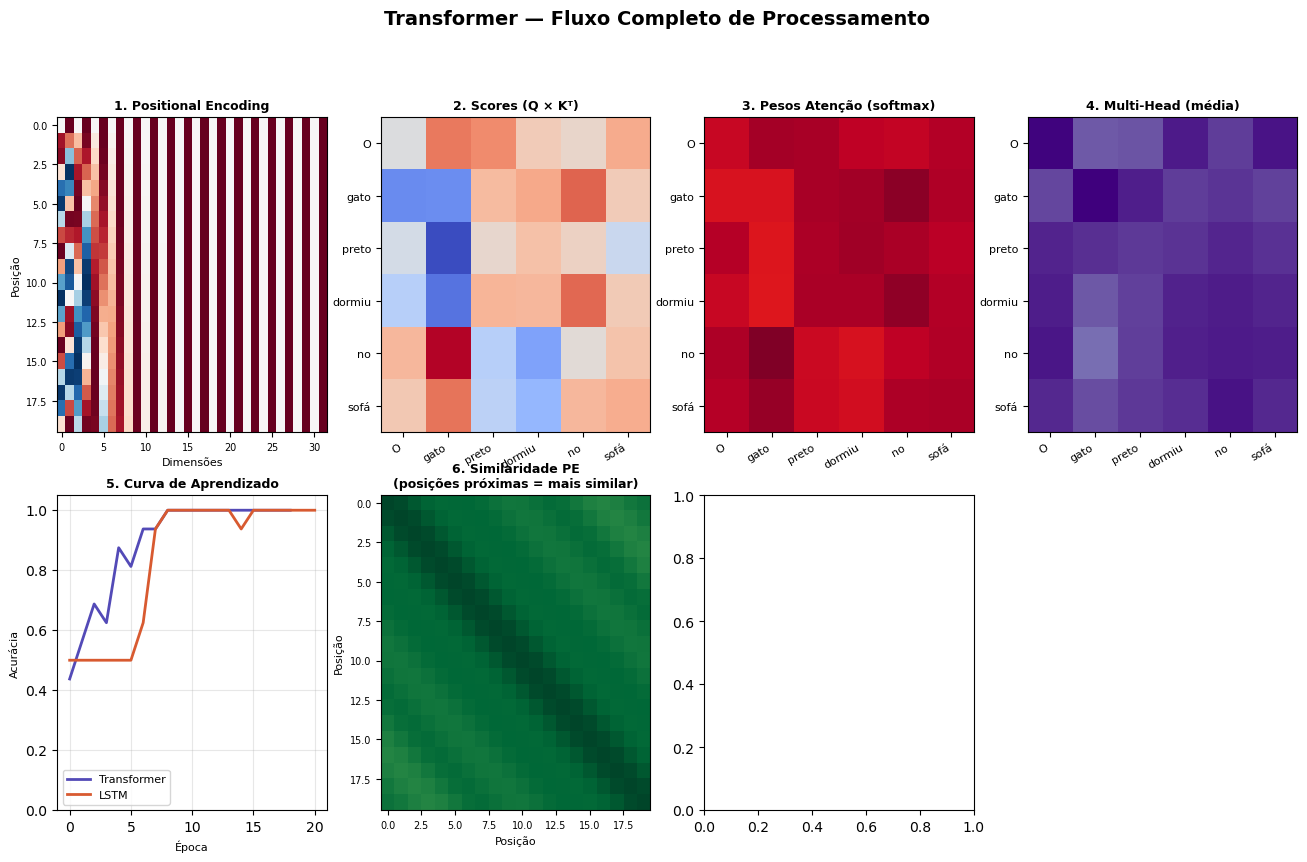

In [15]:
# ─────────────────────────────────────────────────────────────
# RESUMO VISUAL — todo o fluxo do Transformer em um único gráfico
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 9))
fig.suptitle('Transformer — Fluxo Completo de Processamento',
             fontsize=14, fontweight='bold', y=1.0)

# ── Painel 1: Positional Encoding
ax1 = fig.add_subplot(2, 4, 1)
PE_vis = positional_encoding(20, 32)
ax1.imshow(PE_vis, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax1.set_title('1. Positional Encoding', fontweight='bold', fontsize=9)
ax1.set_xlabel('Dimensões', fontsize=8)
ax1.set_ylabel('Posição', fontsize=8)
ax1.tick_params(labelsize=7)

# ── Painel 2: Matriz Q × K (scores brutos)
ax2 = fig.add_subplot(2, 4, 2)
scores_brutos = Q @ K.T
ax2.imshow(scores_brutos, aspect='auto', cmap='coolwarm')
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels(tokens, rotation=30, ha='right', fontsize=8)
ax2.set_yticklabels(tokens, fontsize=8)
ax2.set_title('2. Scores (Q × Kᵀ)', fontweight='bold', fontsize=9)

# ── Painel 3: Pesos após softmax
ax3 = fig.add_subplot(2, 4, 3)
ax3.imshow(pesos_frase, aspect='auto', cmap='YlOrRd', vmin=0)
ax3.set_xticks(range(n))
ax3.set_yticks(range(n))
ax3.set_xticklabels(tokens, rotation=30, ha='right', fontsize=8)
ax3.set_yticklabels(tokens, fontsize=8)
ax3.set_title('3. Pesos Atenção (softmax)', fontweight='bold', fontsize=9)

# ── Painel 4: Multi-Head (4 cabeças)
ax4 = fig.add_subplot(2, 4, 4)
stacked = np.stack(pesos_por_cabeca[:4]).mean(axis=0)
ax4.imshow(stacked, aspect='auto', cmap='Purples', vmin=0)
ax4.set_xticks(range(n))
ax4.set_yticks(range(n))
ax4.set_xticklabels(tokens, rotation=30, ha='right', fontsize=8)
ax4.set_yticklabels(tokens, fontsize=8)
ax4.set_title('4. Multi-Head (média)', fontweight='bold', fontsize=9)

# ── Painel 5: Curvas de treino
ax5 = fig.add_subplot(2, 4, 5)
ax5.plot(hist_tr.history['accuracy'], color='#534AB7', lw=2, label='Transformer')
ax5.plot(hist_rnn.history['accuracy'], color='#D85A30', lw=2, label='LSTM')
ax5.set_title('5. Curva de Aprendizado', fontweight='bold', fontsize=9)
ax5.set_xlabel('Época', fontsize=8)
ax5.set_ylabel('Acurácia', fontsize=8)
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)
ax5.set_ylim(0, 1.05)

# ── Painel 6: PE similaridade entre posições
ax6 = fig.add_subplot(2, 4, 6)
PE_sim = np.array([[np.dot(PE[i], PE[j]) / (
    np.linalg.norm(PE[i]) * np.linalg.norm(PE[j]))
    for j in range(20)] for i in range(20)])
ax6.imshow(PE_sim, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
ax6.set_title('6. Similaridade PE\n(posições próximas = mais similar)',
              fontweight='bold', fontsize=9)
ax6.set_xlabel('Posição', fontsize=8)
ax6.set_ylabel('Posição', fontsize=8)
ax6.tick_params(labelsize=7)

# ── Painel 7: BERT — atenção da cabeça 1
ax7 = fig.add_subplot(2, 4, 7)
pesos_h1 = atencoes[0][0, 0].detach().numpy()[:n_tok, :n_tok]
ax7.imshow(pesos_h1, aspect='auto', cmap='Blues', vmin=0)
ax7.set_xticks(range(n_tok))
ax7.set_yticks(range(n_tok))
ax7.set_xticklabels(tokens_exib, rotation=45, ha='right', fontsize=7)
ax7.set_yticklabels(tokens_exib, fontsize=7)
ax7.set_title('7. BERT real — cabeça 1', fontweight='bold', fontsize=9)

# ── Painel 8: Tabela comparativa
ax8 = fig.add_subplot(2, 4, 8)
ax8.axis('off')
tabela = [
    ['Aspecto', 'RNN/LSTM', 'Transformer'],
    ['Paralelismo', 'Não', 'Sim'],
    ['Ctx. longa', 'Difícil', 'Direto'],
    ['Escalável', 'Limitado', 'Muito'],
    ['Ano', '1997/97', '2017'],
    ['Modelos', 'LSTM, GRU', 'BERT, GPT'],
]
tab = ax8.table(cellText=tabela[1:], colLabels=tabela[0],
                 cellLoc='center', loc='center',
                 colColours=['#EEEDFE', '#FAECE7', '#E1F5EE'])
tab.auto_set_font_size(False)
tab.set_fontsize(9)
tab.scale(1, 1.4)
ax8.set_title('8. Comparativo final', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

---
## 📝 Resumo do Notebook

| Parte | O que implementamos | Conceito central |
|---|---|---|
| 1 | Scaled Dot-Product Attention do zero | Q×Kᵀ/√d → softmax → ×V |
| 2 | Positional Encoding com sin/cos | Cada posição tem um código único |
| 3 | Multi-Head Attention manual | H cabeças em paralelo, cada uma foca diferente |
| 4 | Camada e modelo Transformer com Keras | Add&Norm + FFN + residual connections |
| 5 | Pesos reais do DistilBERT | 12 cabeças, 6 camadas, padrões emergentes |
| 6 | RNN vs Transformer | Paralelismo + contexto longo = Transformer vence |
| 7 | Resumo visual completo | Fluxo end-to-end em 8 painéis |

---

## 🔜 Próxima Aula

**Aula 3 — Arquiteturas para PLN**  
Você verá em profundidade como RNNs, LSTMs e GRUs funcionam antes do Transformer,  
entendendo a evolução histórica que tornou o paper de 2017 tão revolucionário.